In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import shapiro
import random


In [ ]:
df = pd.read_csv("dataset.csv")

In [ ]:
print(df.isnull().sum())

MZ-7.86E-05      0
MZ2.18E-07       0
MZ9.60E-05       0
MZ0.000366014    0
MZ0.000810195    0
                ..
MZ19987.596      0
MZ19990.235      0
MZ19992.874      0
MZ19995.513      0
Class            0
Length: 15155, dtype: int64


# DESCRIPTION DATESET (EDA)

In [ ]:
print(df.shape )

(253, 15155)


In [ ]:
df.columns

Index(['MZ-7.86E-05', 'MZ2.18E-07', 'MZ9.60E-05', 'MZ0.000366014',
       'MZ0.000810195', 'MZ0.001428564', 'MZ0.002221123', 'MZ0.003187869',
       'MZ0.004328805', 'MZ0.005643929',
       ...
       'MZ19974.404', 'MZ19977.042', 'MZ19979.68', 'MZ19982.319',
       'MZ19984.957', 'MZ19987.596', 'MZ19990.235', 'MZ19992.874',
       'MZ19995.513', 'Class'],
      dtype='object', length=15155)

In [ ]:
df.head(5)

,MZ-7.86E-05,MZ2.18E-07,MZ9.60E-05,MZ0.000366014,MZ0.000810195,MZ0.001428564,MZ0.002221123,MZ0.003187869,MZ0.004328805,MZ0.005643929,...,MZ19974.404,MZ19977.042,MZ19979.68,MZ19982.319,MZ19984.957,MZ19987.596,MZ19990.235,MZ19992.874,MZ19995.513,Class
0,0.494626,0.263735,0.321841,0.220934,0.297622,0.316458,0.154763,0.223685,0.304346,0.241757,...,0.483622,0.449296,0.449296,0.449296,0.449296,0.449296,0.449296,0.449296,0.449296,Normal
1,0.258063,0.406593,0.321841,0.069771,0.333335,0.354432,0.321431,0.144740,0.260869,0.142853,...,0.631765,0.619718,0.619718,0.619718,0.619718,0.619718,0.619718,0.619718,0.619718,Normal
2,0.537636,0.032966,0.321841,0.209307,0.404762,0.113927,0.369049,0.223685,0.536231,0.131865,...,0.038462,0.035918,0.035918,0.035918,0.035918,0.035918,0.035918,0.035918,0.035918,Normal
3,0.000000,0.395605,0.310347,0.197673,0.404762,0.455701,0.416666,0.210527,0.420292,0.274723,...,0.497864,0.486621,0.486621,0.486621,0.486621,0.486621,0.486621,0.486621,0.486621,Normal
4,0.526884,0.395605,0.367817,0.383719,0.488099,0.392405,0.238094,0.500000,0.362316,0.274723,...,0.267096,0.251408,0.251408,0.251408,0.251408,0.251408,0.251408,0.251408,0.251408,Normal


In [ ]:
df.tail(5)

,MZ-7.86E-05,MZ2.18E-07,MZ9.60E-05,MZ0.000366014,MZ0.000810195,MZ0.001428564,MZ0.002221123,MZ0.003187869,MZ0.004328805,MZ0.005643929,...,MZ19974.404,MZ19977.042,MZ19979.68,MZ19982.319,MZ19984.957,MZ19987.596,MZ19990.235,MZ19992.874,MZ19995.513,Class
248,0.569893,0.681316,0.988506,0.465117,0.690479,0.594937,0.642856,0.842109,0.826085,0.648350,...,0.519231,0.498592,0.498592,0.498592,0.498592,0.498592,0.498592,0.498592,0.498592,Cancer
249,0.569893,0.791209,0.666670,0.651163,0.785715,0.607595,1.000000,0.578952,0.739131,0.648350,...,0.462961,0.450005,0.450005,0.450005,0.450005,0.450005,0.450005,0.450005,0.450005,Cancer
250,0.688175,0.703294,0.655177,0.581398,0.726193,0.772153,0.583334,0.868424,0.768115,0.879119,...,0.527779,0.519718,0.519718,0.519718,0.519718,0.519718,0.519718,0.519718,0.519718,Cancer
251,0.838709,0.824175,0.678164,0.651163,0.809524,0.835442,0.761906,0.842109,0.594200,0.637362,...,0.532050,0.519718,0.519718,0.519718,0.519718,0.519718,0.519718,0.519718,0.519718,Cancer
252,0.795699,0.648350,0.517244,0.790699,0.595238,0.607595,0.678575,0.763158,0.898546,0.725277,...,0.289174,0.273243,0.273243,0.273243,0.273243,0.273243,0.273243,0.273243,0.273243,Cancer


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253 entries, 0 to 252
Columns: 15155 entries, MZ-7.86E-05 to Class
dtypes: float64(15154), object(1)
memory usage: 29.3+ MB


In [ ]:
df.describe()

,MZ-7.86E-05,MZ2.18E-07,MZ9.60E-05,MZ0.000366014,MZ0.000810195,MZ0.001428564,MZ0.002221123,MZ0.003187869,MZ0.004328805,MZ0.005643929,...,MZ19971.766,MZ19974.404,MZ19977.042,MZ19979.68,MZ19982.319,MZ19984.957,MZ19987.596,MZ19990.235,MZ19992.874,MZ19995.513
count,253.000000,253.000000,253.000000,253.000000,253.000000,253.000000,253.000000,253.000000,253.000000,253.000000,...,253.000000,253.000000,253.000000,253.000000,253.000000,253.000000,253.000000,253.000000,253.000000,253.000000
mean,0.532450,0.462623,0.465859,0.421363,0.481133,0.489570,0.466263,0.512587,0.531018,0.447726,...,0.435985,0.443944,0.430548,0.430548,0.430548,0.430548,0.430548,0.430548,0.430548,0.430548
std,0.183136,0.196834,0.196418,0.212991,0.196406,0.185289,0.173548,0.214232,0.215837,0.188748,...,0.160151,0.156482,0.155192,0.155192,0.155192,0.155192,0.155192,0.155192,0.155192,0.155192
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.397850,0.329667,0.321841,0.255817,0.345240,0.354432,0.345240,0.342109,0.362316,0.307689,...,0.324327,0.334049,0.330282,0.330282,0.330282,0.330282,0.330282,0.330282,0.330282,0.330282
50%,0.537636,0.461537,0.459768,0.430235,0.476194,0.468359,0.464290,0.500000,0.536231,0.428571,...,0.441929,0.451566,0.433102,0.433102,0.433102,0.433102,0.433102,0.433102,0.433102,0.433102
75%,0.655912,0.593407,0.597701,0.569765,0.619047,0.620253,0.595238,0.684212,0.710146,0.582418,...,0.544194,0.547010,0.541554,0.541554,0.541554,0.541554,0.541554,0.541554,0.541554,0.541554
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [ ]:
print(df.isnull().values.any())

False


In [ ]:
print("Total Missing Values:", df.isnull().sum().sum())

Total Missing Values: 0


In [ ]:

print(df['Class'].value_counts())
print(df['Class'].value_counts(normalize=True) * 100)

Class
Cancer    162
Normal     91
Name: count, dtype: int64
Class
Cancer    64.031621
Normal    35.968379
Name: proportion, dtype: float64


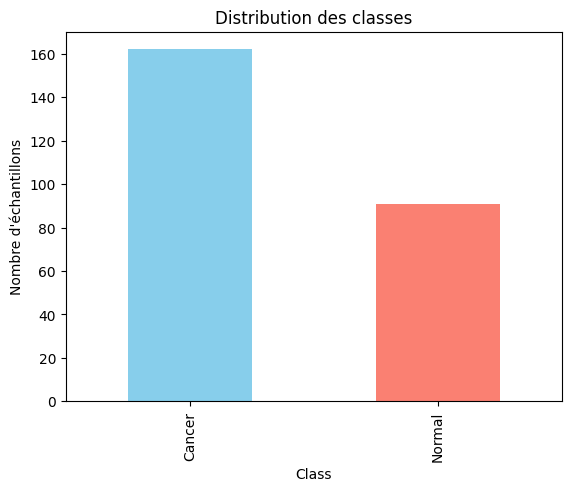

In [ ]:
df['Class'].value_counts().plot(kind='bar', color=['skyblue', 'salmon'])
plt.title('Distribution des classes')
plt.xlabel('Class')
plt.ylabel('Nombre d\'échantillons')
plt.show()

In [ ]:
df_numeric = df.select_dtypes(include=['number'])

def detect_outliers_iqr(df):
    outlier_counts = {}
    for col in df.columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        outliers = df[(df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)]
        outlier_counts[col] = len(outliers)
    return outlier_counts

outlier_counts = detect_outliers_iqr(df_numeric)
sorted_outliers = dict(sorted(outlier_counts.items(), key=lambda item: item[1], reverse=True))

for feature, count in list(sorted_outliers.items())[:20]:
    print(f"{feature}: {count} valeurs aberrantes")

MZ200.17821: 62 valeurs aberrantes
MZ154.0727: 61 valeurs aberrantes
MZ309.81052: 60 valeurs aberrantes
MZ155.00081: 59 valeurs aberrantes
MZ174.14832: 59 valeurs aberrantes
MZ349.44058: 58 valeurs aberrantes
MZ350.48809: 58 valeurs aberrantes
MZ153.84111: 57 valeurs aberrantes
MZ155.23328: 56 valeurs aberrantes
MZ154.53641: 55 valeurs aberrantes
MZ172.1834: 55 valeurs aberrantes
MZ349.78958: 54 valeurs aberrantes
MZ154.30447: 53 valeurs aberrantes
MZ154.76852: 53 valeurs aberrantes
MZ350.83761: 53 valeurs aberrantes
MZ350.13875: 52 valeurs aberrantes
MZ174.39472: 50 valeurs aberrantes
MZ155.46591: 49 valeurs aberrantes
MZ309.48208: 49 valeurs aberrantes
MZ174.64129: 48 valeurs aberrantes


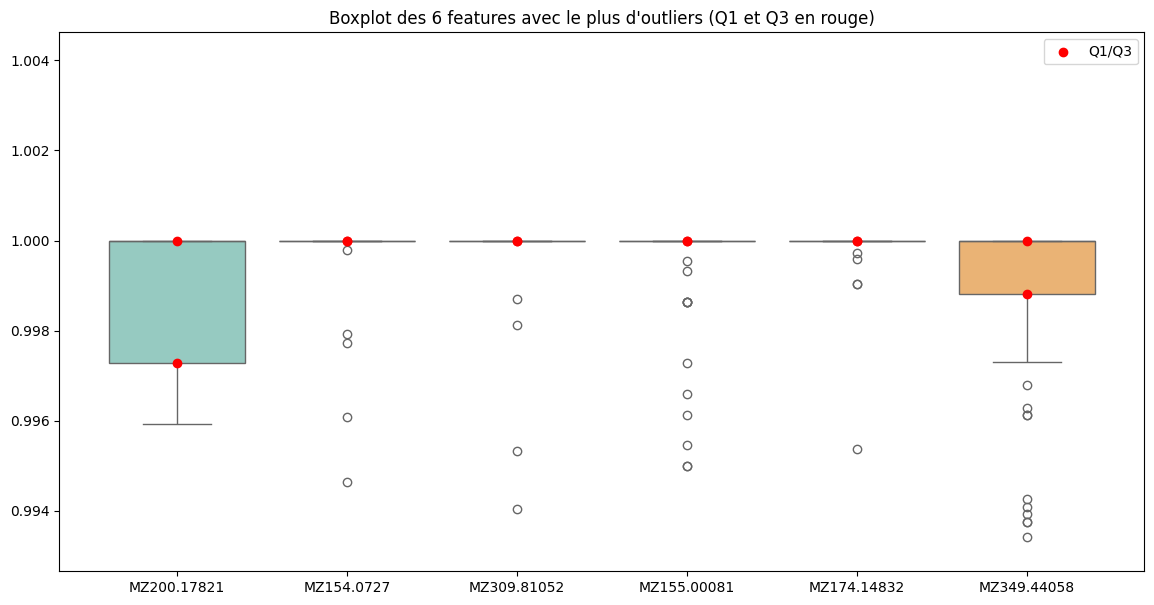

In [ ]:
top6_features = list(sorted_outliers.keys())[:6]
q1 = df_numeric[top6_features].quantile(0.25)
q3 = df_numeric[top6_features].quantile(0.75)
iqr = q3 - q1
lower_lim, upper_lim = (q1 - 1.5*iqr).min(), (q3 + 1.5*iqr).max()
plt.figure(figsize=(14,7))
sns.boxplot(data=df_numeric[top6_features], palette="Set3", showfliers=True)
for i, f in enumerate(top6_features):
    plt.scatter([i, i], [q1[f], q3[f]], color='red', zorder=10, label='Q1/Q3' if i==0 else "")
plt.ylim(lower_lim - 0.05*(upper_lim-lower_lim), upper_lim + 0.05*(upper_lim-lower_lim))
plt.title("Boxplot des 6 features avec le plus d'outliers (Q1 et Q3 en rouge)")
plt.legend()
plt.show()

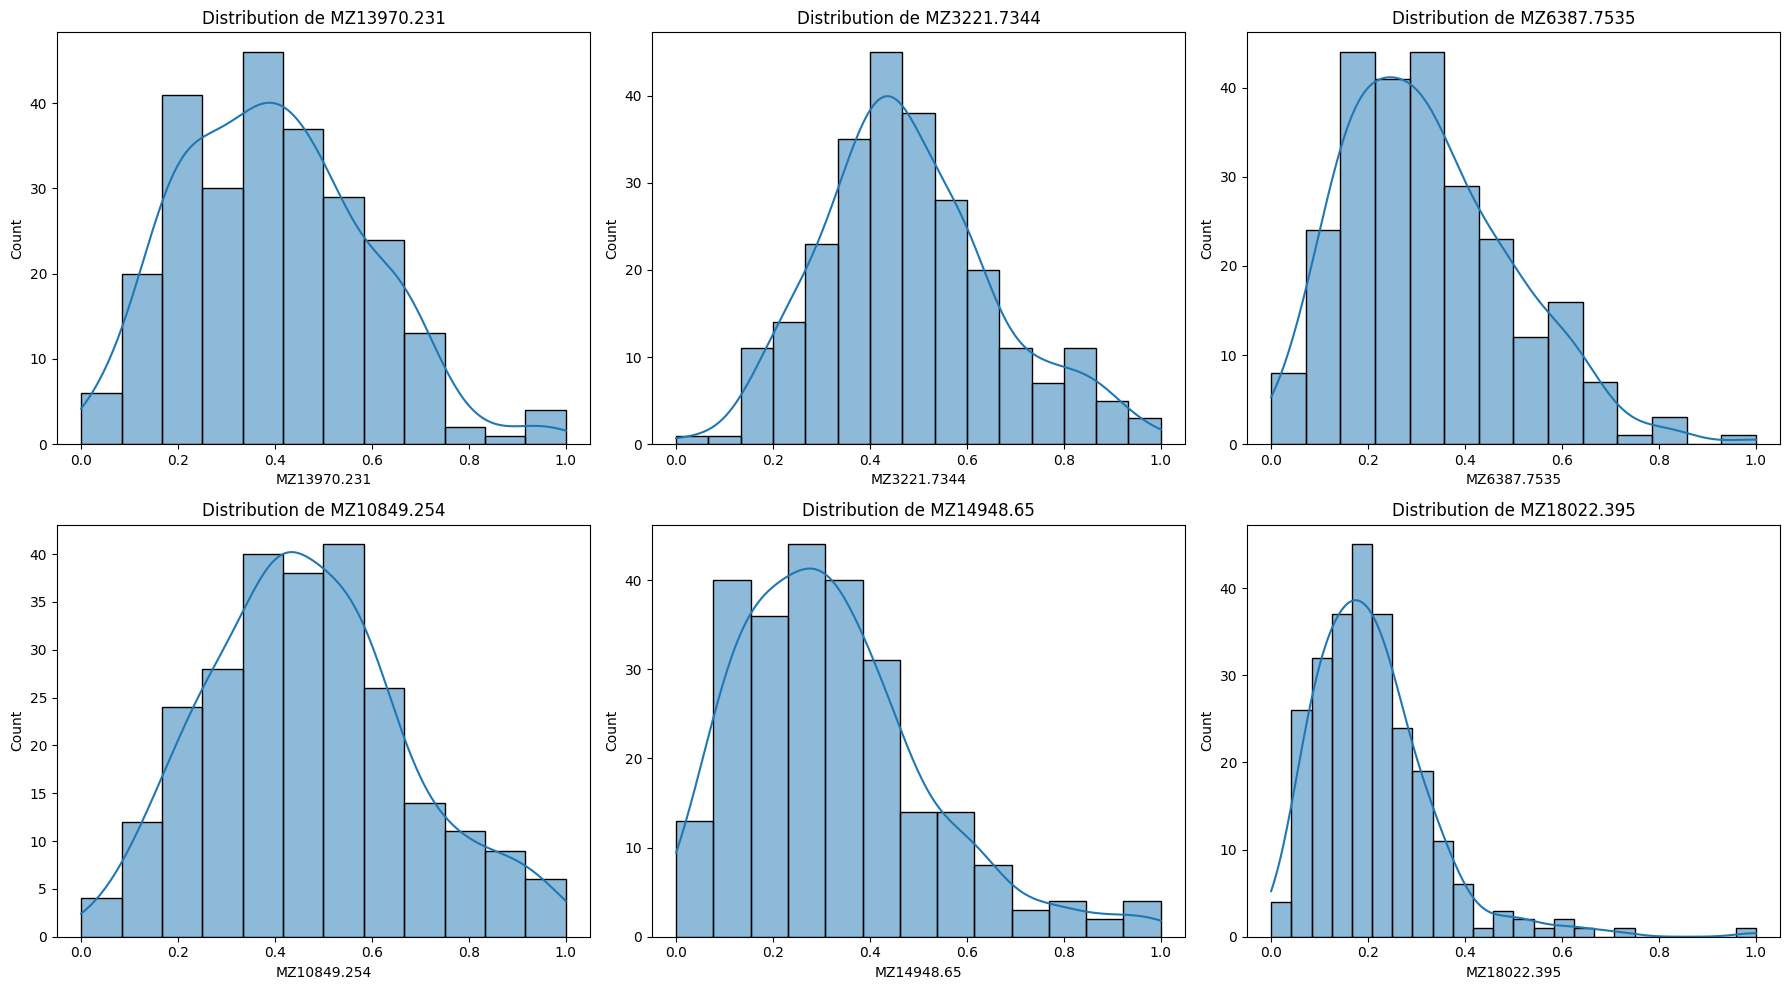

=== Feature: MZ13970.231 ===
p-value = 0.003554735293254908
Feature ne suit pas une distribution normale

=== Feature: MZ3221.7344 ===
p-value = 0.0016878018125724792
Feature ne suit pas une distribution normale

=== Feature: MZ6387.7535 ===
p-value = 4.887573948642311e-06
Feature ne suit pas une distribution normale

=== Feature: MZ10849.254 ===
p-value = 0.009600788281685323
Feature ne suit pas une distribution normale

=== Feature: MZ14948.65 ===
p-value = 7.361400992199271e-09
Feature ne suit pas une distribution normale

=== Feature: MZ18022.395 ===
p-value = 1.2963696832064748e-13
Feature ne suit pas une distribution normale



In [ ]:

features = random.sample(list(df.columns[:-1]), 6)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, feature in enumerate(features):
    sns.histplot(df[feature], kde=True, ax=axes[i])
    axes[i].set_title(f'Distribution de {feature}')

plt.tight_layout()
plt.show()

for feature in features:
    print(f"=== Feature: {feature} ===")
    stat, p = shapiro(df[feature])
    print('p-value =', p)
    if p > 0.05:
        print('Feature suit une distribution normale\n')
    else:
        print('Feature ne suit pas une distribution normale\n')

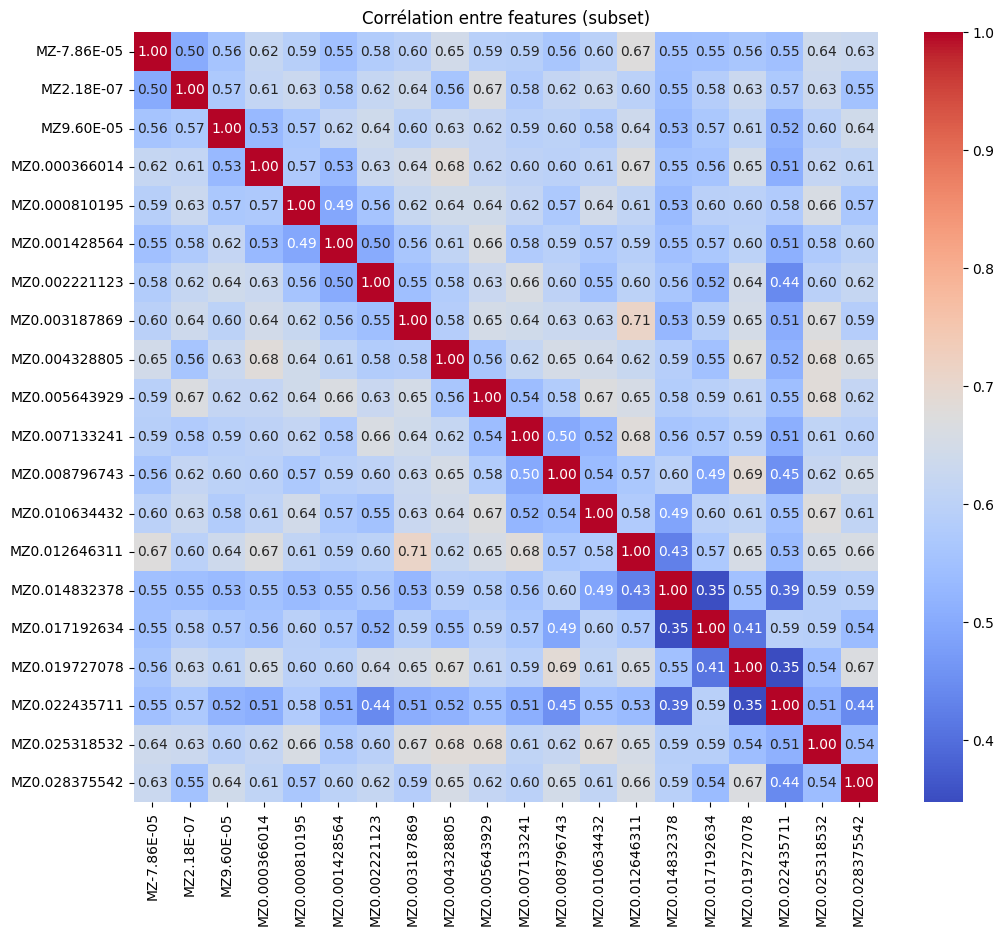

In [ ]:

subset_features = df.columns[:20]
corr_matrix = df[subset_features].corr()

plt.figure(figsize=(12,10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Corrélation entre features (subset)")
plt.show()



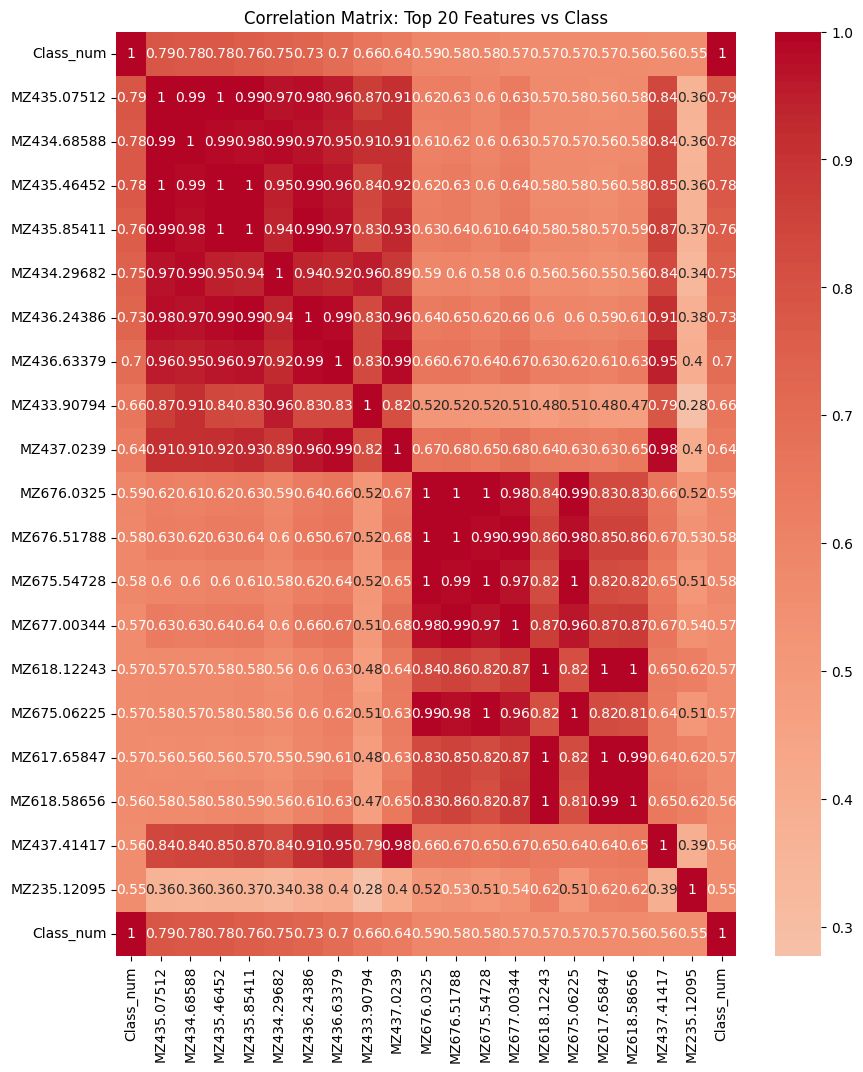

In [ ]:
df['Class_num'] = df['Class'].apply(lambda x: 1 if x=='Cancer' else 0)
numeric_df = df.select_dtypes(include='number')

correlation_with_class = numeric_df.corr()['Class_num'].sort_values(ascending=False)


top_features = correlation_with_class.head(20).index.tolist()

plt.figure(figsize=(10,12))
sns.heatmap(df[top_features + ['Class_num']].corr(), annot=True, cmap='coolwarm', center=0)
plt.title("Correlation Matrix: Top 20 Features vs Class")
plt.show()

In [ ]:
df['Class_num'] = df['Class'].map({'Normal':0, 'Cancer':1})

Top 20 features les plus corrélées avec la classe:
Class_num      1.000000
MZ435.07512    0.785921
MZ434.68588    0.777766
MZ435.46452    0.776659
MZ435.85411    0.761906
MZ434.29682    0.748643
MZ436.24386    0.732990
MZ436.63379    0.695581
MZ433.90794    0.657007
MZ437.0239     0.640999
MZ676.0325     0.588718
MZ676.51788    0.584355
MZ675.54728    0.583531
MZ677.00344    0.570524
MZ618.12243    0.568950
MZ675.06225    0.567082
MZ617.65847    0.565422
MZ618.58656    0.564155
MZ437.41417    0.558021
MZ235.12095    0.554711
Name: Class_num, dtype: float64


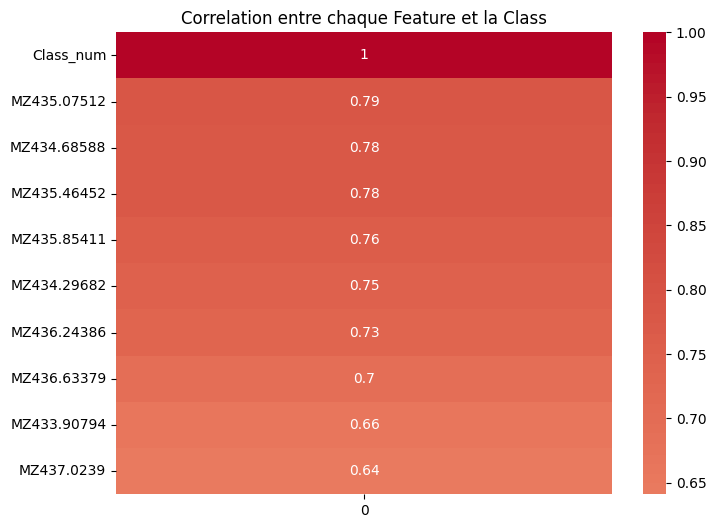

In [ ]:
df['Class_num'] = df['Class'].apply(lambda x: 1 if x=='Cancer' else 0)
numeric_df = df.select_dtypes(include='number')
correlation_with_class = numeric_df.corr()['Class_num'].sort_values(ascending=False)
print("Top 20 features les plus corrélées avec la classe:")
print(correlation_with_class.head(20))
top_features = correlation_with_class.head(10).index
plt.figure(figsize=(8,6))
sns.heatmap(df[top_features].corrwith(df['Class_num']).to_frame(), annot=True, cmap='coolwarm', center=0)
plt.title('Correlation entre chaque Feature et la Class')
plt.show()

# MODELS SANS PRETRETEMENT

In [ ]:
print(df.isnull().sum())

MZ-7.86E-05      0
MZ2.18E-07       0
MZ9.60E-05       0
MZ0.000366014    0
MZ0.000810195    0
                ..
MZ19990.235      0
MZ19992.874      0
MZ19995.513      0
Class            0
Class_num        0
Length: 15156, dtype: int64


In [ ]:

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report,confusion_matrix
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split

In [ ]:
df['Class_num'] = df['Class'].apply(lambda x: 1 if x=='Cancer' else 0)

KNN Performance:
Accuracy: 0.9314
Precision: 0.9265
Recall: 0.9692
F1-score: 0.9474

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.86      0.90        37
           1       0.93      0.97      0.95        65

    accuracy                           0.93       102
   macro avg       0.93      0.92      0.92       102
weighted avg       0.93      0.93      0.93       102



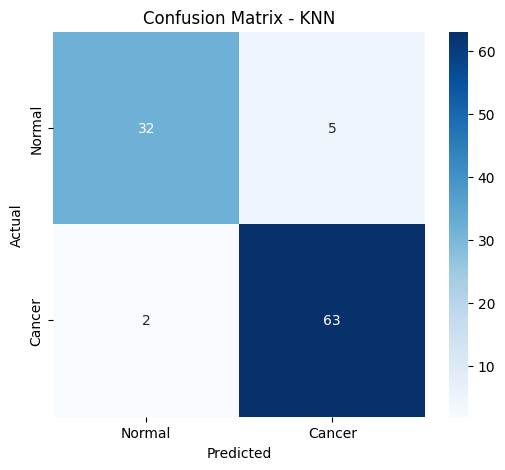

In [ ]:
X = df.drop(['Class', 'Class_num'], axis=1)
y = df['Class_num']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=42)

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("KNN Performance:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Normal','Cancer'], yticklabels=['Normal','Cancer'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - KNN')
plt.show()

SVM Performance:
Accuracy: 0.9804
Precision: 1.0000
Recall: 0.9692
F1-score: 0.9844

Classification Report:
              precision    recall  f1-score   support

           0       0.95      1.00      0.97        37
           1       1.00      0.97      0.98        65

    accuracy                           0.98       102
   macro avg       0.97      0.98      0.98       102
weighted avg       0.98      0.98      0.98       102



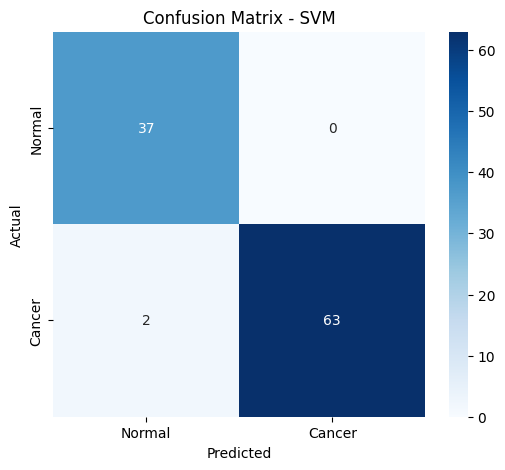

In [ ]:
svm_model = SVC(kernel='rbf', C=1, gamma='scale')
svm_model.fit(X_train, y_train)
y_pred = svm_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("SVM Performance:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Normal','Cancer'], yticklabels=['Normal','Cancer'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - SVM')
plt.show()

Decision Tree Performance:
Accuracy: 0.9118
Precision: 0.9516
Recall: 0.9077
F1-score: 0.9291

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.92      0.88        37
           1       0.95      0.91      0.93        65

    accuracy                           0.91       102
   macro avg       0.90      0.91      0.91       102
weighted avg       0.91      0.91      0.91       102



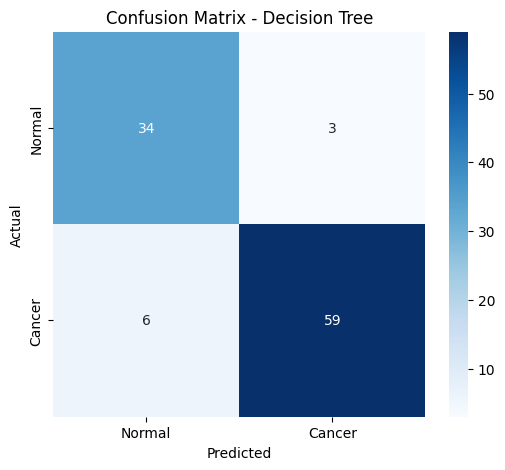

In [ ]:


dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
y_pred = dt_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Decision Tree Performance:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Normal','Cancer'], yticklabels=['Normal','Cancer'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Decision Tree')
plt.show()

Naive Bayes Performance:
Accuracy: 0.9020
Precision: 0.9661
Recall: 0.8769
F1-score: 0.9194

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.95      0.88        37
           1       0.97      0.88      0.92        65

    accuracy                           0.90       102
   macro avg       0.89      0.91      0.90       102
weighted avg       0.91      0.90      0.90       102



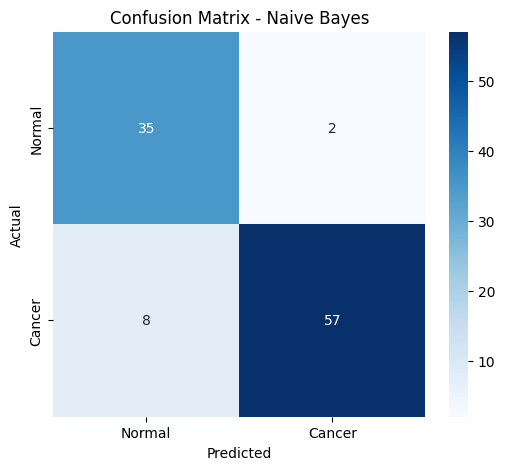

In [ ]:
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)
y_pred = nb_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Naive Bayes Performance:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Normal','Cancer'], yticklabels=['Normal','Cancer'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Naive Bayes')
plt.show()

SVM Execution Time: 0.3666 seconds
Decision Tree Execution Time: 0.6307 seconds
Naive Bayes Execution Time: 0.1405 seconds
KNN Execution Time: 0.1357 seconds


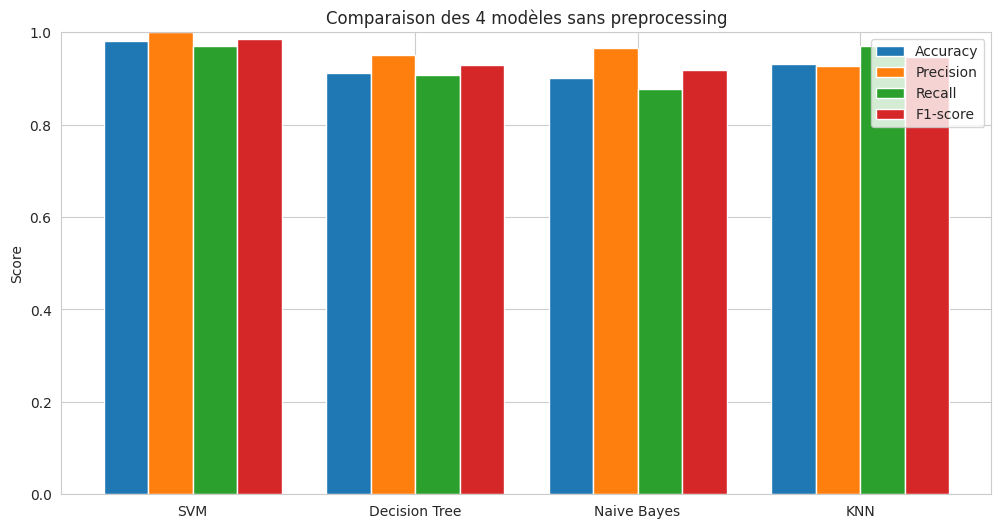

In [ ]:
import time

models = {
    "SVM": SVC(kernel='rbf', C=1, gamma='scale'),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Naive Bayes": GaussianNB(),
    "KNN": KNeighborsClassifier(n_neighbors=5)
}

metrics = {"Accuracy": [], "Precision": [], "Recall": [], "F1-score": [], "Time": []}

for name, model in models.items():

    start = time.time()

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    end = time.time()
    execution_time = end - start

    metrics["Accuracy"].append(accuracy_score(y_test, y_pred))
    metrics["Precision"].append(precision_score(y_test, y_pred))
    metrics["Recall"].append(recall_score(y_test, y_pred))
    metrics["F1-score"].append(f1_score(y_test, y_pred))
    metrics["Time"].append(execution_time)

    print(f"{name} Execution Time: {execution_time:.4f} seconds")

plt.figure(figsize=(12,6))
sns.set_style("whitegrid")

bar_width = 0.2
x = range(len(models))

plt.bar([i-bar_width*1.5 for i in x], metrics["Accuracy"], width=bar_width, label="Accuracy")
plt.bar([i-bar_width/2 for i in x], metrics["Precision"], width=bar_width, label="Precision")
plt.bar([i+bar_width/2 for i in x], metrics["Recall"], width=bar_width, label="Recall")
plt.bar([i+bar_width*1.5 for i in x], metrics["F1-score"], width=bar_width, label="F1-score")

plt.xticks(x, list(models.keys()))
plt.ylim(0,1)
plt.ylabel("Score")
plt.title("Comparaison des 4 modèles sans preprocessing")
plt.legend()
plt.show()

# PRETRETEMENT ETAPE

In [ ]:
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.decomposition import PCA
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D



In [ ]:
X = df.drop("Class", axis=1)
y = df["Class"]

In [ ]:
X_scaled = StandardScaler().fit_transform(X)
n_features = X.shape[1]
n_samples = X.shape[0]

In [ ]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="mean")
X_clean = imputer.fit_transform(X_scaled)

In [ ]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE
import numpy as np

# 1. Imputation
imputer = SimpleImputer(strategy="mean")
X_clean = imputer.fit_transform(X_scaled)

# 2. Encode labels
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# 3. SMOTE
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X_clean, y_encoded)

print("Après SMOTE:")
print(np.bincount(y_res))

Après SMOTE:
[162 162]


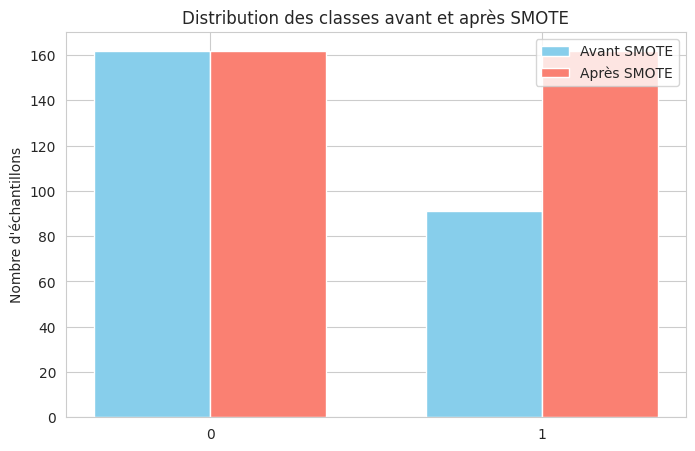

In [ ]:
le = LabelEncoder()
y_encoded = le.fit_transform(y)
y_res_encoded = le.fit_transform(y_res)

counts_original = np.bincount(y_encoded)
counts_resampled = np.bincount(y_res_encoded)

labels = le.classes_
x = np.arange(len(labels))
width = 0.35

plt.figure(figsize=(8,5))
plt.bar(x - width/2, counts_original, width, label='Avant SMOTE', color='skyblue')
plt.bar(x + width/2, counts_resampled, width, label='Après SMOTE', color='salmon')

plt.xticks(x, labels)
plt.ylabel("Nombre d'échantillons")
plt.title("Distribution des classes avant et après SMOTE")
plt.legend()
plt.show()

In [ ]:
max_components = min(n_samples, n_features)


pca_full = PCA(n_components=max_components)
pca_full.fit(X_scaled)

explained_var_ratio = pca_full.explained_variance_ratio_
cumulative_var = explained_var_ratio.cumsum()


pca_table = pd.DataFrame({
    'Component': [f'PC{i+1}' for i in range(max_components)],
    'Variance (%)': explained_var_ratio*100,
    'Cumulative Variance (%)': cumulative_var*100
})

print(" PCA Summary Table ")
print(pca_table)

 PCA Summary Table 
    Component  Variance (%)  Cumulative Variance (%)
0         PC1  3.042353e+01                30.423532
1         PC2  2.746900e+01                57.892528
2         PC3  1.034961e+01                68.242138
3         PC4  7.563684e+00                75.805823
4         PC5  3.657250e+00                79.463073
..        ...           ...                      ...
248     PC249  3.572830e-03                99.989695
249     PC250  3.536963e-03                99.993232
250     PC251  3.405194e-03                99.996637
251     PC252  3.363147e-03               100.000000
252     PC253  3.742906e-31               100.000000

[253 rows x 3 columns]


In [ ]:

features = X.columns
features = np.array(features)

pca = PCA(n_components=min(X_scaled.shape))
X_pca = pca.fit_transform(X_scaled)

explained_var_ratio = pca.explained_variance_ratio_
cumulative_var = np.cumsum(explained_var_ratio)


threshold = 0.90

n_components_85 = np.argmax(cumulative_var >= threshold)

print("Number of components to cover 90% variance:", n_components_85)


weight_threshold = 0.40

top_features_dict = {}

for i in range(n_components_85):

    component = pca.components_[i]

    abs_weights = np.abs(component)

    sorted_idx = np.argsort(-abs_weights)

    sorted_weights = abs_weights[sorted_idx]

    sorted_features = features[sorted_idx]

    cum_weights = np.cumsum(sorted_weights) / np.sum(sorted_weights)

    n_top = np.searchsorted(cum_weights, weight_threshold)

    top_features_dict[f'PC{i+1}'] = sorted_features[:n_top]


for pc, feats in top_features_dict.items():

    print("\n", pc, "top features (95% weight):")
    print(list(feats))


Number of components to cover 90% variance: 12

 PC1 top features (95% weight):
['MZ17465.486', 'MZ17453.155', 'MZ17467.953', 'MZ17455.62', 'MZ17470.42', 'MZ17458.087', 'MZ17460.553', 'MZ17463.019', 'MZ17472.887', 'MZ17450.689', 'MZ17480.289', 'MZ17477.822', 'MZ17445.758', 'MZ17448.223', 'MZ17443.293', 'MZ17440.828', 'MZ17475.354', 'MZ17438.363', 'MZ17482.757', 'MZ17428.505', 'MZ17430.969', 'MZ17426.041', 'MZ17435.898', 'MZ17433.434', 'MZ17487.693', 'MZ17485.225', 'MZ17421.114', 'MZ17418.65', 'MZ17490.162', 'MZ17423.577', 'MZ17416.187', 'MZ17492.63', 'MZ17495.099', 'MZ17413.724', 'MZ17411.261', 'MZ17497.568', 'MZ17500.037', 'MZ17408.798', 'MZ17502.506', 'MZ17406.335', 'MZ17504.975', 'MZ17507.445', 'MZ17403.873', 'MZ17509.915', 'MZ17401.411', 'MZ17512.384', 'MZ17514.855', 'MZ17398.949', 'MZ17517.325', 'MZ17396.487', 'MZ17519.795', 'MZ17394.025', 'MZ17524.737', 'MZ17522.266', 'MZ17527.208', 'MZ17391.563', 'MZ17529.679', 'MZ17389.102', 'MZ17532.15', 'MZ17386.641', 'MZ17534.622', 'MZ17537.

In [ ]:

important_features = []

for feats in top_features_dict.values():
    important_features.extend(list(feats))


important_features = list(set(important_features))

print("\nImportant Features used for correlation:")
print(important_features)


corr_matrix = X[important_features].corr().round(3)

print("\nCorrelation Matrix of Important Features:\n")
print(corr_matrix)

corr_table = corr_matrix.reset_index()
corr_table = corr_table.rename(columns={"index": "Feature"})

print("\nCorrelation Matrix Table:\n")
print(corr_table)



Important Features used for correlation:
['MZ3392.3846', 'MZ12410.343', 'MZ6072.5054', 'MZ11454.31', 'MZ28.600577', 'MZ20.406579', 'MZ15861.299', 'MZ313.10452', 'MZ9800.7853', 'MZ17342.369', 'MZ3616.659', 'MZ8646.9223', 'MZ10628.755', 'MZ3180.5493', 'MZ389.61084', 'MZ4476.236', 'MZ2763.6114', 'MZ0.019727078', 'MZ2482.6628', 'MZ9120.1074', 'MZ2744.0219', 'MZ69.150274', 'MZ815.00995', 'MZ2376.8644', 'MZ4443.827', 'MZ13445.781', 'MZ6084.1469', 'MZ451.5802', 'MZ2246.7499', 'MZ7301.3988', 'MZ13335.629', 'MZ2698.2611', 'MZ894.6628', 'MZ5814.9434', 'MZ4070.0545', 'MZ5239.2722', 'MZ164.67465', 'MZ86.928905', 'MZ14419.418', 'MZ2028.4924', 'MZ6420.6144', 'MZ7191.7668', 'MZ267.65685', 'MZ217.7113', 'MZ7155.407', 'MZ4009.5521', 'MZ15884.815', 'MZ13012.146', 'MZ15099.645', 'MZ14247.355', 'MZ17463.019', 'MZ3884.0883', 'MZ5412.2559', 'MZ15526.932', 'MZ4541.4074', 'MZ148.56256', 'MZ11174.379', 'MZ6776.8883', 'MZ13385.249', 'MZ8525.8554', 'MZ16668.19', 'MZ2397.8398', 'MZ19346.32', 'MZ19937.49', 'MZ456

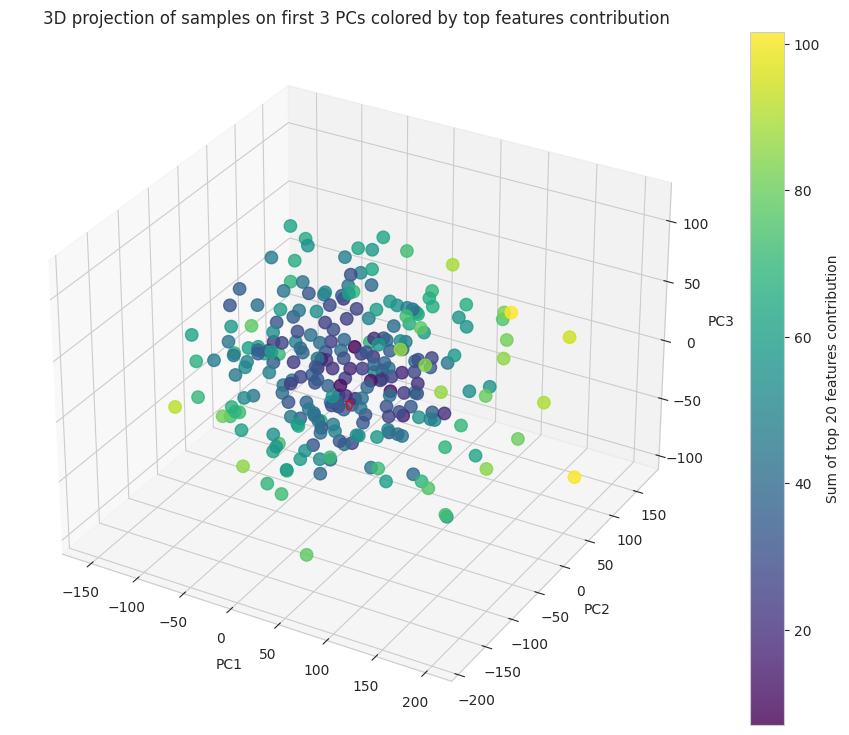

In [ ]:

top_n = 20
top_features_3pcs = list(set([f for feats in list(top_features_dict.values())[:3] for f in feats[:top_n]]))

contrib_df = pd.DataFrame(X_scaled[:, [np.where(features==f)[0][0] for f in top_features_3pcs]],
                          columns=top_features_3pcs, index=X.index)

sample_contrib = np.abs(contrib_df).sum(axis=1)

X_pca_df = pd.DataFrame(X_pca[:, :3], columns=['PC1','PC2','PC3'], index=X.index)

fig = plt.figure(figsize=(12,9))
ax = fig.add_subplot(111, projection='3d')

sc = ax.scatter(X_pca_df['PC1'], X_pca_df['PC2'], X_pca_df['PC3'],
                c=sample_contrib, cmap='viridis', s=80, alpha=0.8)

fig.colorbar(sc, label='Sum of top 20 features contribution')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
ax.set_title('3D projection of samples on first 3 PCs colored by top features contribution')

sample_to_annotate = X.index[0]
ax.text(X_pca_df.loc[sample_to_annotate,'PC1'],
        X_pca_df.loc[sample_to_annotate,'PC2'],
        X_pca_df.loc[sample_to_annotate,'PC3'],
        sample_to_annotate, color='red')

plt.show()


In [ ]:
top_n = 20

top_features_3pcs = []
for feats in list(top_features_dict.values())[:3]:
    for f in feats[:top_n]:
        if f not in top_features_3pcs:
            top_features_3pcs.append(f)

print("Top features (ordered):")
for i, f in enumerate(top_features_3pcs):
    print(i+1, f)

Top features (ordered):
1 MZ17465.486
2 MZ17453.155
3 MZ17467.953
4 MZ17455.62
5 MZ17470.42
6 MZ17458.087
7 MZ17460.553
8 MZ17463.019
9 MZ17472.887
10 MZ17450.689
11 MZ17480.289
12 MZ17477.822
13 MZ17445.758
14 MZ17448.223
15 MZ17443.293
16 MZ17440.828
17 MZ17475.354
18 MZ17438.363
19 MZ17482.757
20 MZ17428.505
21 MZ2705.0521
22 MZ2704.0815
23 MZ2703.111
24 MZ2706.023
25 MZ2742.0668
26 MZ2737.1821
27 MZ2738.1587
28 MZ2706.994
29 MZ2699.2307
30 MZ2728.4006
31 MZ2741.0895
32 MZ2734.2534
33 MZ2736.2057
34 MZ2740.1124
35 MZ2707.9652
36 MZ2698.2611
37 MZ2861.6051
38 MZ2752.8286
39 MZ2735.2294
40 MZ2702.1406
41 MZ2666.361
42 MZ3970.645
43 MZ3969.4689
44 MZ3971.8212
45 MZ8028.3671
46 MZ8030.0396
47 MZ8026.6948
48 MZ8031.7122
49 MZ8025.0227
50 MZ8033.3851
51 MZ8023.3507
52 MZ4066.483
53 MZ4028.4845
54 MZ3889.9067
55 MZ8035.0581
56 MZ8021.6789
57 MZ8036.7312
58 MZ3985.9494
59 MZ8038.4046
60 MZ3972.9976


In [ ]:
X_pca[:, :20]
X_pca_5 = X_pca[:, :5]

In [ ]:
import pandas as pd

df_top5 = pd.DataFrame({
    "Rank": range(1, 6),
    "Feature": top_features_3pcs[:5]
})

df_top5

,Rank,Feature
0,1,MZ17465.486
1,2,MZ17453.155
2,3,MZ17467.953
3,4,MZ17455.62
4,5,MZ17470.42


In [ ]:
import pandas as pd

df_top5 = pd.DataFrame({
    "Rank": range(1, 9),
    "Feature": top_features_3pcs[:8]
})

df_top5

,Rank,Feature
0,1,MZ17465.486
1,2,MZ17453.155
2,3,MZ17467.953
3,4,MZ17455.62
4,5,MZ17470.42
5,6,MZ17458.087
6,7,MZ17460.553
7,8,MZ17463.019


In [ ]:

models = {
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "SVM": SVC(kernel='rbf', probability=True),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Naive Bayes": GaussianNB()
}


for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)

    print(f"\n===== {name} =====")
    print(f"Accuracy: {acc:.4f}")
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    print("Classification Report:")
    print(classification_report(y_test, y_pred))



===== KNN =====
Accuracy: 0.9314
Confusion Matrix:
[[32  5]
 [ 2 63]]
Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.86      0.90        37
           1       0.93      0.97      0.95        65

    accuracy                           0.93       102
   macro avg       0.93      0.92      0.92       102
weighted avg       0.93      0.93      0.93       102


===== SVM =====
Accuracy: 0.9804
Confusion Matrix:
[[37  0]
 [ 2 63]]
Classification Report:
              precision    recall  f1-score   support

           0       0.95      1.00      0.97        37
           1       1.00      0.97      0.98        65

    accuracy                           0.98       102
   macro avg       0.97      0.98      0.98       102
weighted avg       0.98      0.98      0.98       102


===== Decision Tree =====
Accuracy: 0.9118
Confusion Matrix:
[[34  3]
 [ 6 59]]
Classification Report:
              precision    recall  f1-score   support


In [ ]:

n_plot = min(7, X_pca.shape[1])

sample_scores_df = pd.DataFrame(X_pca[:, :n_plot],
                                columns=[f'PC{i+1}' for i in range(n_plot)],
                                index=X.index)

print("Scores des samples sur les 12 premiers PCA components:")
print(sample_scores_df)

Scores des samples sur les 12 premiers PCA components:
            PC1         PC2        PC3        PC4        PC5        PC6  \
0     33.021061  -66.212447   2.116268 -22.120104   2.292850  24.490218   
1     97.502111 -101.950434 -27.489058 -25.066302   6.404653  -5.414759   
2   -114.415162   -4.390096  45.376948  -7.886215  14.710111   7.058842   
3     93.843962   30.078587  22.859564 -30.431323  60.445277  35.937746   
4    -70.953185  -43.770764  15.929797   1.041970  21.966189 -11.154562   
..          ...         ...        ...        ...        ...        ...   
248   30.424897  169.603469  -2.241653   2.867913  -6.812912  29.449239   
249   30.566935  170.811472 -21.930003  31.460988   5.551349   9.811762   
250   -8.993569  129.424410 -12.142179  47.306662 -43.334939  -9.837351   
251   36.128238   54.793001  38.823671 -10.966893 -30.674967  20.230857   
252 -151.257109   74.327922 -24.425154   5.815165  15.896795  -2.614504   

           PC7  
0   -10.897430  
1    -9.64


Model: SVM
Accuracy: 0.9705882352941176
Execution Time: 0.0060 seconds
Classification Report:
               precision    recall  f1-score   support

      Cancer       0.96      1.00      0.98        65
      Normal       1.00      0.92      0.96        37

    accuracy                           0.97       102
   macro avg       0.98      0.96      0.97       102
weighted avg       0.97      0.97      0.97       102


Model: KNN
Accuracy: 0.9509803921568627
Execution Time: 0.0026 seconds
Classification Report:
               precision    recall  f1-score   support

      Cancer       0.94      0.98      0.96        65
      Normal       0.97      0.89      0.93        37

    accuracy                           0.95       102
   macro avg       0.96      0.94      0.95       102
weighted avg       0.95      0.95      0.95       102


Model: Naive Bayes
Accuracy: 0.9509803921568627
Execution Time: 0.0012 seconds
Classification Report:
               precision    recall  f1-score   supp

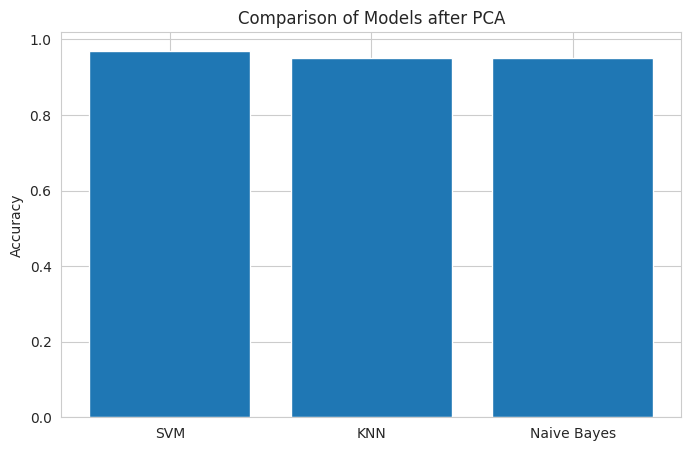


Execution Time for each model:
SVM: 0.0060 seconds
KNN: 0.0026 seconds
Naive Bayes: 0.0012 seconds


In [ ]:
import time
import matplotlib.pyplot as plt

X_pca_final = X_pca[:, :n_components_85]

X_train, X_test, y_train, y_test = train_test_split(
    X_pca_final, y, test_size=0.4, random_state=42, stratify=y
)

smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)

models = {
    'SVM': SVC(kernel='rbf', probability=True, random_state=42),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'Naive Bayes': GaussianNB()
}

results = {}
times = {}

for name, model in models.items():

    start_time = time.time()

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    end_time = time.time()
    execution_time = end_time - start_time

    acc = accuracy_score(y_test, y_pred)

    print(f"\nModel: {name}")
    print("Accuracy:", acc)
    print(f"Execution Time: {execution_time:.4f} seconds")
    print("Classification Report:\n", classification_report(y_test, y_pred))

    results[name] = acc
    times[name] = execution_time

plt.figure(figsize=(8,5))
plt.bar(results.keys(), results.values())
plt.ylabel('Accuracy')
plt.title('Comparison of Models after PCA')
plt.show()

print("\nExecution Time for each model:")
for model, t in times.items():
    print(f"{model}: {t:.4f} seconds")


Model: Decision Tree
Accuracy: 1.0
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        33
           1       1.00      1.00      1.00        32

    accuracy                           1.00        65
   macro avg       1.00      1.00      1.00        65
weighted avg       1.00      1.00      1.00        65



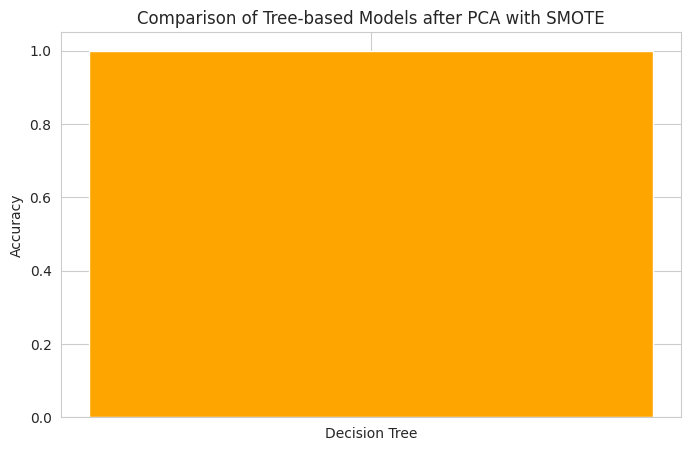

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_res, y_res, test_size=0.2, random_state=42, stratify=y_res
)

models = {
    'Decision Tree': DecisionTreeClassifier(random_state=42)
}

results = {}

for name, model in models.items():
    start_time = time.time()

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    end_time = time.time()
    acc = accuracy_score(y_test, y_pred)
    print(f"\nModel: {name}")
    print("Accuracy:", acc)
    print("Classification Report:\n", classification_report(y_test, y_pred))
    results[name] = acc

plt.figure(figsize=(8,5))
plt.bar(results.keys(), results.values(), color=['orange'])
plt.ylabel('Accuracy')
plt.title('Comparison of Tree-based Models after PCA with SMOTE')
plt.show()


Model: Decision Tree
Accuracy: 1.0
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        33
           1       1.00      1.00      1.00        32

    accuracy                           1.00        65
   macro avg       1.00      1.00      1.00        65
weighted avg       1.00      1.00      1.00        65



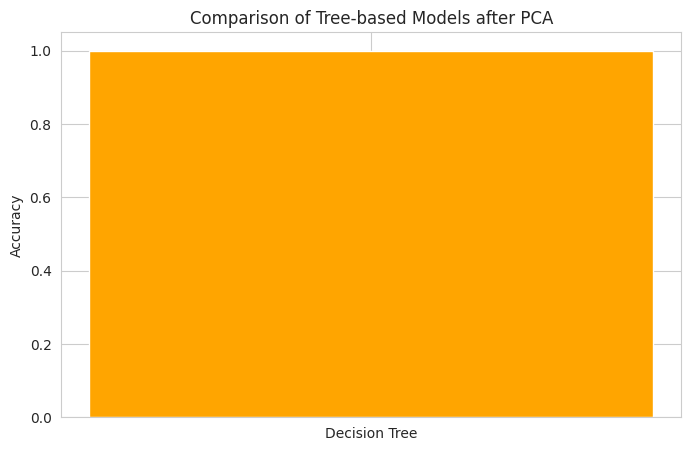

In [ ]:

models = {
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    }

results = {}


for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    print(f"\nModel: {name}")
    print("Accuracy:", acc)
    print("Classification Report:\n", classification_report(y_test, y_pred))

    results[name] = acc

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.bar(results.keys(), results.values(), color=['orange','lightblue','lightgreen'])
plt.ylabel('Accuracy')
plt.title('Comparison of Tree-based Models after PCA')
plt.show()